# Graphicalizing Aesop's Fables

This notebook downloads the public-domain Project Gutenberg text for [Æsop's Fables #53103](https://www.gutenberg.org/ebooks/53103), splits it into tale-sized documents, and sends those documents through the ontology-guided semantic pipeline.

The notebook uses the package's default OpenAI `gpt-4.1-mini` client. Set `OPENAI_API_KEY` in the environment before running the model cell. The key is read by the OpenAI SDK and is never stored in this notebook.

In [11]:
%config InlineBackend.figure_format = 'retina'

%load_ext autoreload
%autoreload 2

from pathlib import Path
from textwrap import wrap

from IPython.display import display

from semantic_graphicalizer import SemanticGraphicalizer, load_aesop_fables

ROOT = Path.cwd()
if not (ROOT / 'configs').exists():
    ROOT = ROOT.parent

stories = load_aesop_fables(limit=1, cache_dir=ROOT / 'data' / 'raw', select_at_random=True, rand_seed=None)
[(story.splitlines()[0], len(story)) for story in stories]

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


[('THE SUN AND THE WIND', 972)]

## OpenAI model

The transformer creates the default `OpenAIModelClient` when `model` is omitted. It uses `gpt-4.1-mini` through the Responses API and reads `OPENAI_API_KEY` from the environment.

In [12]:
from textwrap import wrap

graphicalizer = SemanticGraphicalizer(
    ontology=ROOT / 'configs' / 'ontologies' / 'aesop.yaml',
    prompts=ROOT / 'configs' / 'prompts' / 'aesop.yaml',
)

graphicalizer.fit(stories)
traces = []

for index, story in enumerate(stories, start=1):
    trace = graphicalizer.transform_with_trace([story])[0]
    traces.append(trace)
    title = story.splitlines()[0]
    print(f"\nDocument {index}/{len(stories)}: {title}")
    print("\n".join(wrap(story, width=80)))
    print(f"ID: {trace.document_id}")
    print(f"Entities: {len(trace.entities)} | Relations: {len(trace.relations)} | "
          f"Nodes: {trace.graph.number_of_nodes()} | Edges: {trace.graph.number_of_edges()}")
    print("-" * 80)
    for relation in trace.relations:
        arguments = ", ".join(f"{argument.role}={argument.entity_id}" for argument in relation.arguments)
        print(f"- {relation.type}[{relation.relation}]({arguments})")
    print("\nGraph:")
    display(graphicalizer.display(trace.graph, mode="text"))
    print("=" * 80)


[SemanticGraphicalizer] ready: model=OpenAIModelClient, ontology=aesop-narrative, domain=aesop-narrative
[document-127171afb681] segment: 1 -> 1 | 0.0 ms | input_chars=972, chunk_chars=972
[document-127171afb681 chunk-0] summarize: 1 -> 1 | 2193.8 ms
[document-127171afb681 chunk-0] normalize: 1 -> 1 | 2287.7 ms
[document-127171afb681 chunk-0] decompose: 1 -> 9 | 6372.8 ms
[document-127171afb681 chunk-0] extract: 9 -> 21 | 19034.3 ms
[document-127171afb681] resolve: 23 -> 2 | 4186.3 ms
[document-127171afb681] integrate: 12 -> 24 | 0.8 ms | nodes=23, edges=24
[document-127171afb681] total: 1 -> 1 | 34076.3 ms | chunks=1, entities=11, relations=12, nodes=23, edges=24

Document 1/1: THE SUN AND THE WIND
THE SUN AND THE WIND   [Illustration: The Sun and The Wind]  [Illustrations]  A
dispute once arose between the Sun and the Wind, which was the stronger of the
two, and they agreed to count this as proof, that whichever soonest made a
traveller take off his cloak, should be held the most pow

character: the Sun
    interacts_with: character: the Wind
    wants: goal: to make a traveler remove his cloak first
    performs: action: a shining action
    teaches: moral: gentle means often achieve what force cannot
character: the Wind
    wants: goal: to make a traveler remove his cloak first
    performs: action: a strong blowing action
character: a traveler
    has_trait: trait: pleasant heat
    performs: action: sat down overcome by it
    performs: action: removed his cloak
action: a strong blowing action
    [causal] causes: action: to wrap his cloak tighter
action: to wrap his cloak tighter
    [temporal] after: action: a strong blowing action
action: removed his cloak
    [temporal] after: action: sat down overcome by it

In [17]:
graphicalizer.display(
    traces[0].graph,
    mode="dynamic",
    layout="force",
    show_derived_links=True,
    show_source=True,
    max_width=34,
    width=1200,
    height=760,
    charge_strength=-10,
    link_distance=150,
    component_spacing=100,
    component_strength=0.3,
    parallel_edge_spacing=320
)

## Convert to AbstractGraph and visualize

The AbstractGraph display shows the reified base graph and its interpretation graph, including their mapping. Interpretation labels use the entity type alone, so the same type has the same label across chunks; document and chunk identifiers remain in metadata. The layout uses undirected Kamada–Kawai distances by default while drawing the original directed edges.

<Axes: >

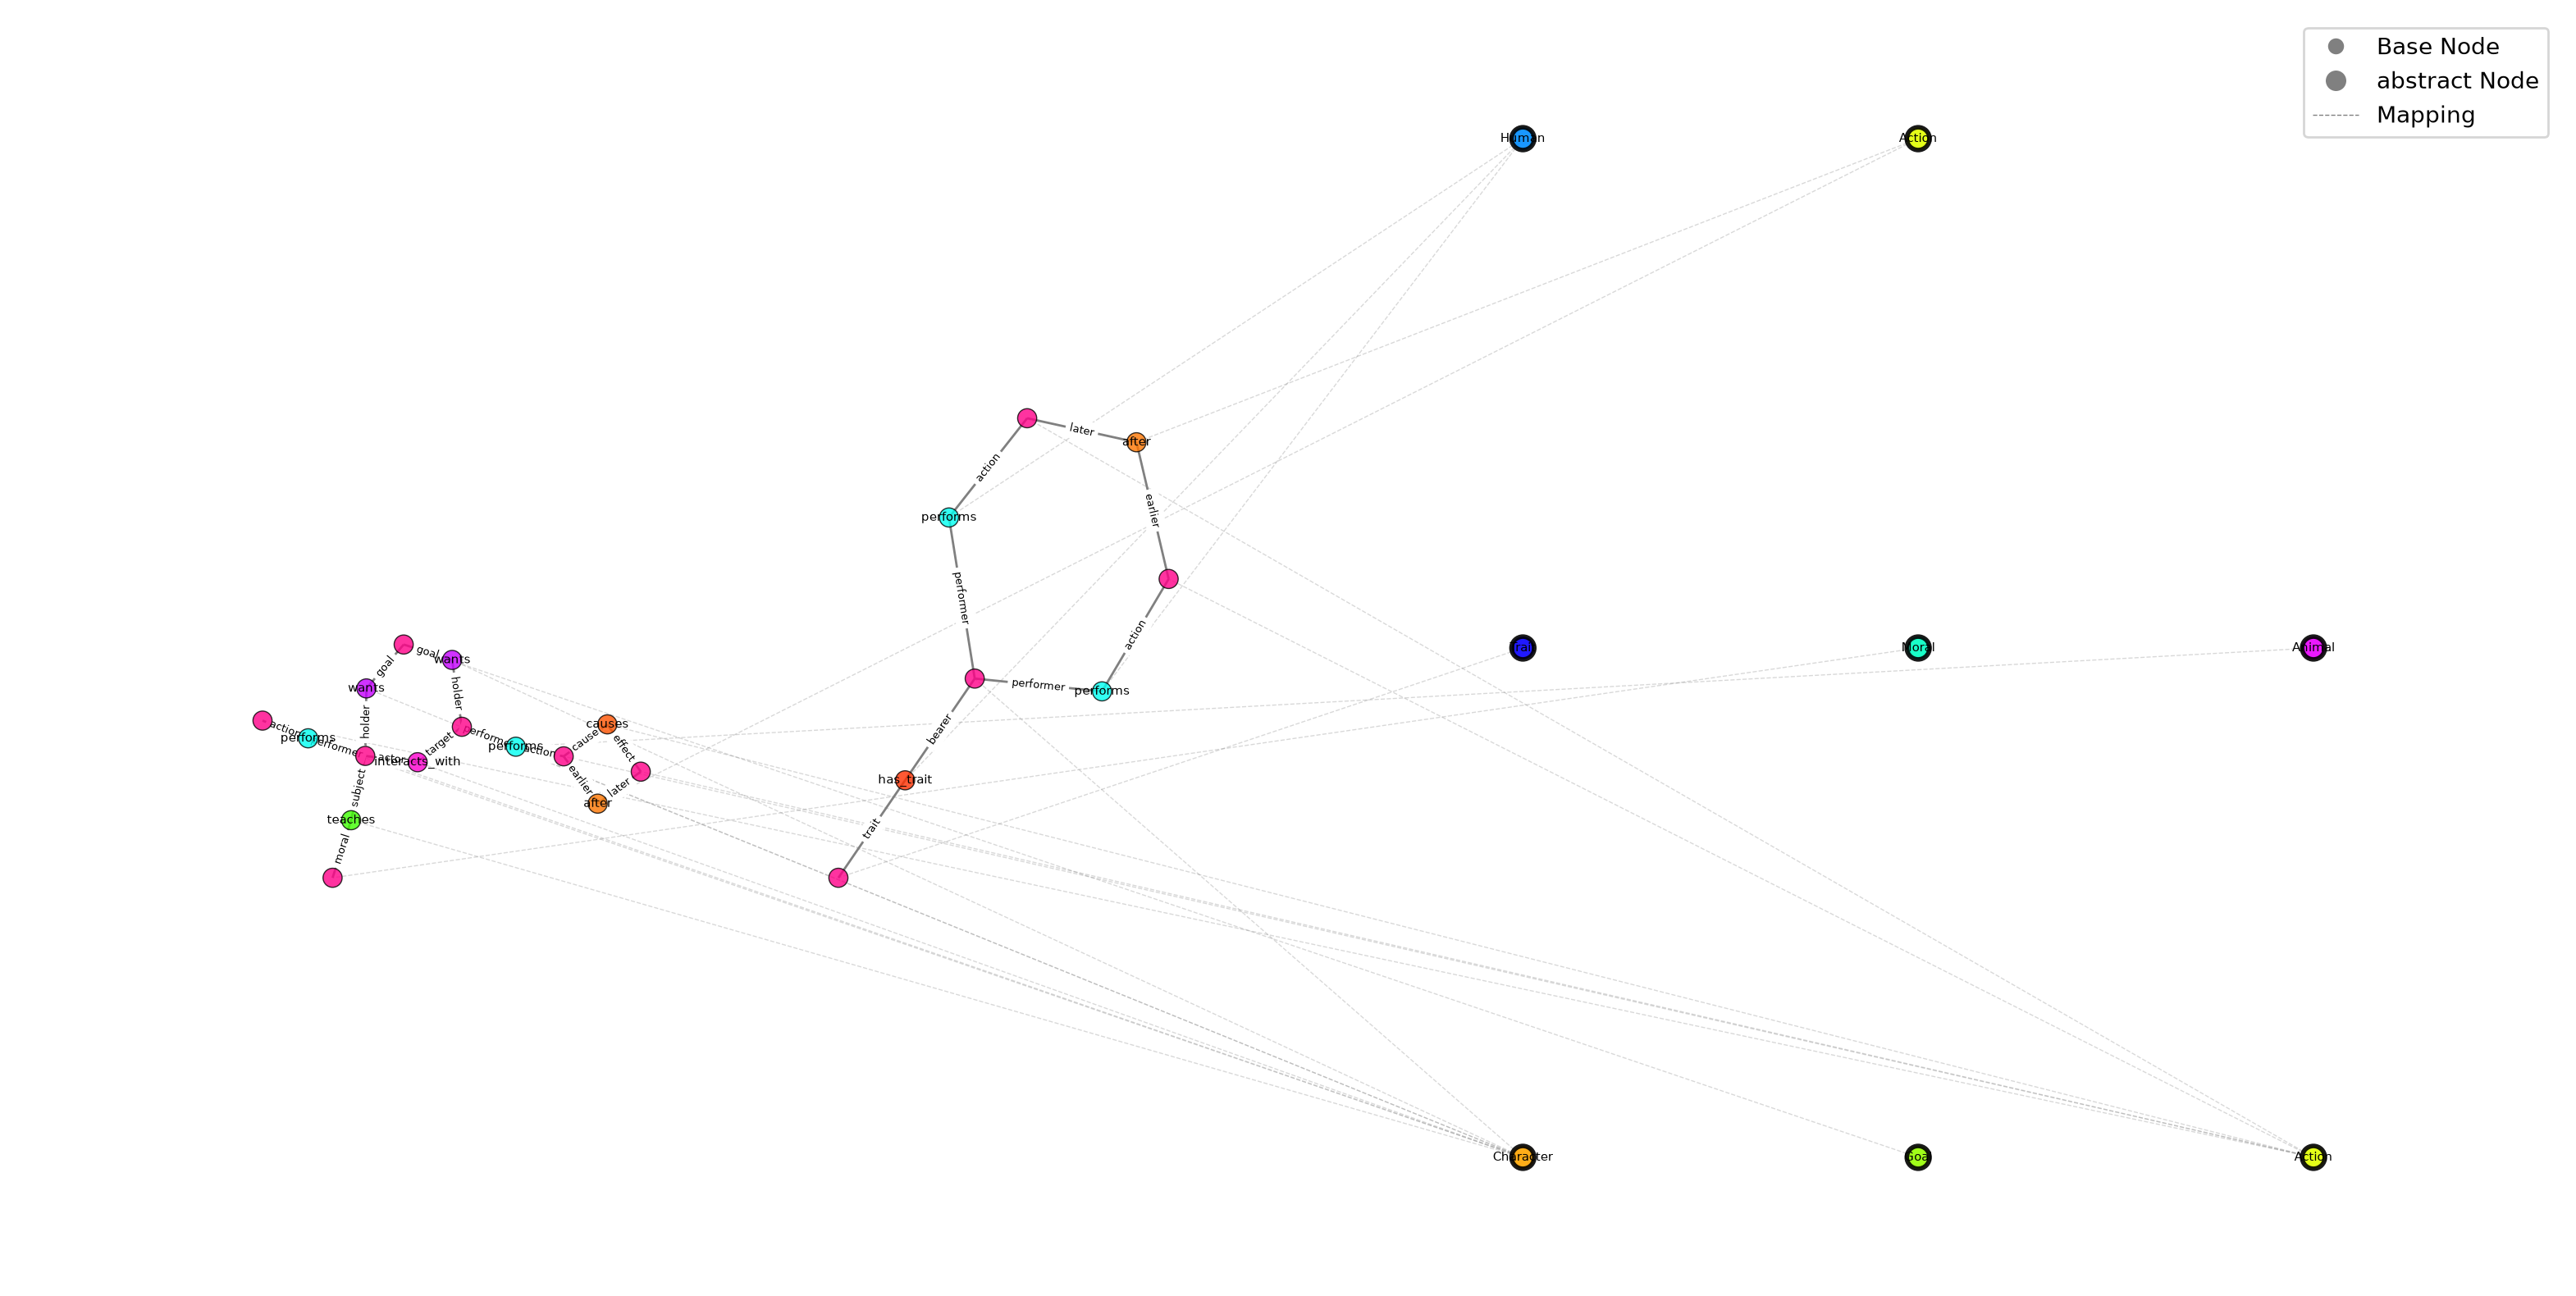

In [18]:
from abstractgraph import display as display_abstract_graph

abstract_graph = graphicalizer.to_abstract_graph(
    traces[0],
    preserve_direction=False,
    embed_nodes=True,
    parallel_edge_policy="combine",
)

display_abstract_graph(
    abstract_graph,
    size=(20, 10),
    show_legend=True,
    node_labels=True,
    node_label_attr="label",
    node_label_font_size=5.5,
    edge_labels=True,
    edge_label_font_size=4.5,
    undirected_layout=True,
)